# Graphs and Spatial Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/graphs_and_spatial.ipynb)

Spatial data come on graphs: the pixels of a raster form a lattice, scattered sensors form a nearest-neighbour or proximity graph, and areal units form a contiguity graph. kernellib stores all of them as sparse `Graph` / `GridGraph` objects whose Laplacians are gaussx operators, and builds spatial models on their spectra. This notebook tours the pieces at the scale each one is meant for.

**What you'll learn:**

1. Why a raster's lattice graph has closed-form, Kronecker-structured Laplacian eigenpairs, and how to get them for a million-pixel grid with `laplacian_eigpairs`.
2. How to draw graph Matérn prior samples on a k-NN graph of scattered points, from `matern_graph_kernel` or directly from the Laplacian spectrum, and what $\nu$ and the lengthscale do.
3. How to build parameter-free proximity graphs (Delaunay, Gabriel, relative neighbourhood) on irregular sites, and an ICAR / Besag prior on them with `structure_matrix` and `graph_null_space`.
4. Where to go for spatial-spectral embeddings of images.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import importlib.util
import logging
import time
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import einx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

import kernellib as kl
from kernellib.functional import graph_matern_spectrum


jax.config.update("jax_enable_x64", True)

In [3]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,gaussx,matplotlib,kernellib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.17.1

jax       : 0.11.2
gaussx    : 0.6.1
matplotlib: 3.11.2
kernellib : 0.0.16

Compiler    : Clang 21.1.4 
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. A raster as a grid graph

A raster of shape $H \times W$ is a lattice: `grid_graph((H, W))` joins every pixel to its 4 face neighbours, numbering pixels in row-major order so that `einx.id("h w -> (h w)", image)` is the matching vector. A `GridGraph` never stores its edges. With face connectivity its Laplacian is the **Kronecker sum** of two path Laplacians,

$$L = L_H \oplus L_W = L_H \otimes I_W + I_H \otimes L_W,$$

and a path Laplacian on $n$ nodes has the closed-form (DCT-II) eigenpairs $\lambda_k = 2 - 2\cos(\pi k / n)$, $k = 0, \dots, n - 1$. Kronecker sums add eigenvalues and multiply eigenvectors, $(L_H \oplus L_W)(u_i \otimes v_j) = (\lambda_i + \mu_j)(u_i \otimes v_j)$, so the smallest eigenpairs of the full grid only need the eigenpairs of the two 1-D factors and a sort of $HW$ sums. `laplacian_eigpairs` picks this path automatically for a face-connected `GridGraph`.

The synthetic raster below has $1000 \times 1000 = 10^6$ pixels: a smooth field plus a sharp-edged disc plus noise.

In [4]:
n_side = 1000
yy, xx = np.mgrid[0:n_side, 0:n_side] / n_side
smooth = np.sin(3 * np.pi * xx) * np.cos(2 * np.pi * yy)
disc = ((xx - 0.65) ** 2 + (yy - 0.35) ** 2 < 0.15**2).astype(float)
noise = 0.3 * np.random.default_rng(0).normal(size=(n_side, n_side))
raster = jnp.asarray(smooth + disc + noise)

grid = kl.grid_graph(raster.shape)
print(f"{type(grid).__name__} with {grid.n_nodes:,} nodes")
print(f"Laplacian operator: {type(grid.laplacian_operator()).__name__}")

GridGraph with 1,000,000 nodes


Laplacian operator: KroneckerSum


Timing the 16 smallest eigenpairs, after a warm-up call so that JAX's compilation is not counted:

In [5]:
n_eig = 16
lam, U = kl.laplacian_eigpairs(grid, n_eig)  # warm-up
U.block_until_ready()

start = time.perf_counter()
lam, U = kl.laplacian_eigpairs(grid, n_eig)
U.block_until_ready()
t_grid = time.perf_counter() - start

path = kl.grid_graph((n_side,)).laplacian_operator().as_matrix()
start = time.perf_counter()
jnp.linalg.eigh(path)[1].block_until_ready()
t_path = time.perf_counter() - start

print(f"{n_eig} eigenpairs of the 10^6-node grid: {t_grid:.1f} s")
print(f"one dense eigh of a {n_side}-node path Laplacian: {t_path:.1f} s")
print(f"eigenvector matrix: {U.shape}, {U.nbytes / 1e6:.0f} MB")

16 eigenpairs of the 10^6-node grid: 17.7 s
one dense eigh of a 1000-node path Laplacian: 8.3 s
eigenvector matrix: (1000000, 16), 128 MB


Nothing of size $N \times N$ was formed (a dense Laplacian would take 8 TB in float64). The time is dominated by the dense eigendecompositions of the two $1000 \times 1000$ path Laplacians, compare the two timings above; the rest is a sort of $10^6$ eigenvalue sums and the outer products of the selected eigenvectors. (These timings come from a shared 16-core machine under heavy load; on an idle CPU a $1000 \times 1000$ `eigh` takes well under a second.) The eigenvalues agree with the closed form:

In [6]:
k = jnp.arange(n_side)
path_lam = 2 - 2 * jnp.cos(jnp.pi * k / n_side)
sums = einx.add("a, b -> (a b)", path_lam, path_lam)
closed_form = jnp.sort(sums)[:n_eig]
print("first eigenvalues:", np.round(np.asarray(lam[:6]), 7))
rel_err = jnp.max(jnp.abs(lam[1:] - closed_form[1:]) / closed_form[1:])
print(f"max relative error vs 2 - 2cos(pi k / n) sums: {float(rel_err):.1e}")

first eigenvalues: [0.00e+00 9.90e-06 9.90e-06 1.97e-05 3.95e-05 3.95e-05]


max relative error vs 2 - 2cos(pi k / n) sums: 6.2e-11


The eigenvectors are products of cosines along each axis, $u_i \otimes v_j$. The first is the constant vector. On a square grid $\lambda_i + \mu_j = \lambda_j + \mu_i$, so most eigenvalues come in pairs whose eigenvectors are the same pattern rotated by 90°; within a repeated eigenvalue only the eigenspace is unique, and another solver could return any rotation of the pair.

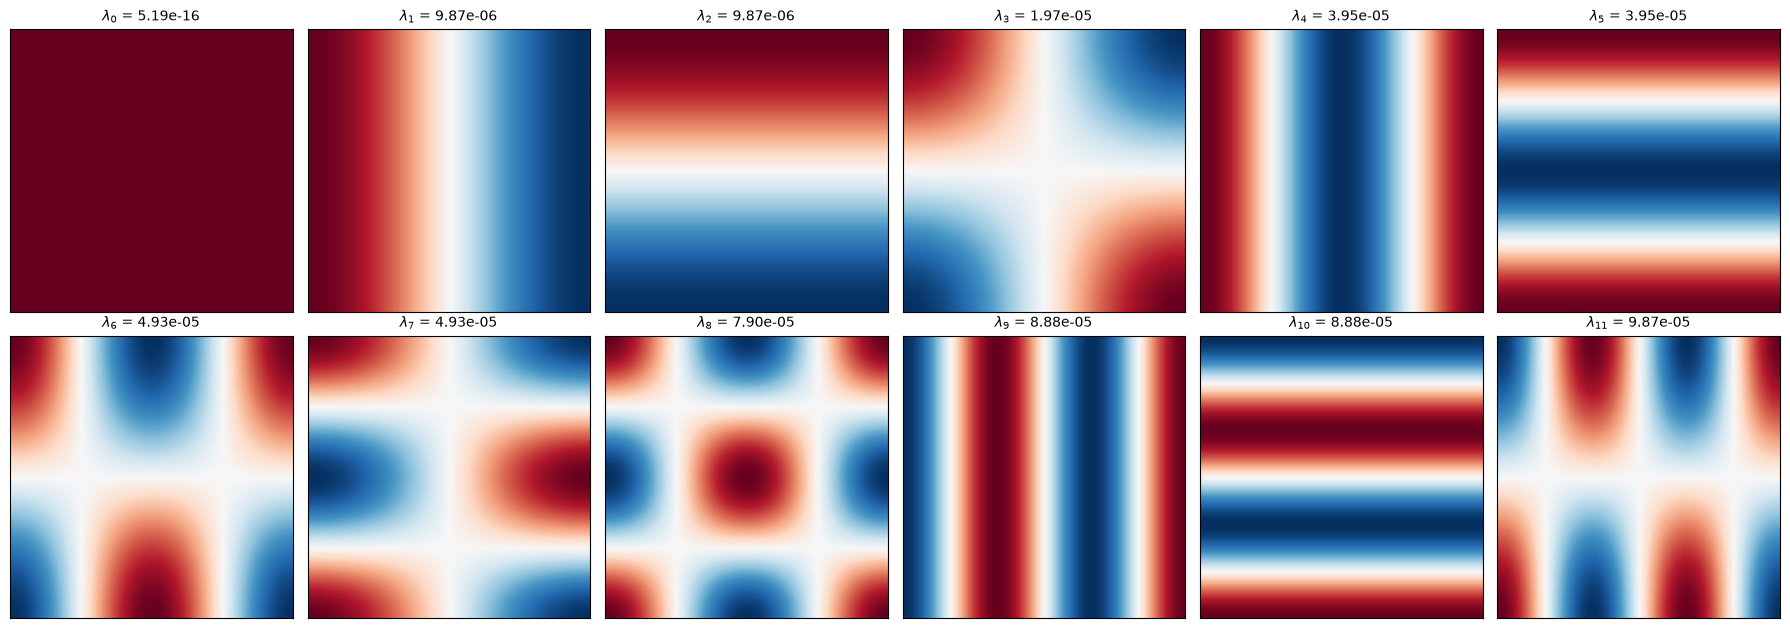

In [7]:
images = einx.id("(h w) n -> n h w", U, h=n_side)
fig, axes = plt.subplots(2, 6, figsize=(18, 6.4))
for j, ax in enumerate(axes.flat):
    vmax = float(jnp.max(jnp.abs(images[j])))
    ax.imshow(images[j, ::8, ::8], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"$\\lambda_{{{j}}}$ = {float(lam[j]):.2e}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

These eigenvectors are the graph's Fourier basis, ordered from smooth to rough. Projecting the raster onto the first 16 is a low-pass filter on the lattice, and the Dirichlet energy $f^\top L f = \sum_{i \sim j} (f_i - f_j)^2$ (`GridGraph.dirichlet_energy`) measures roughness without forming $L$:

Dirichlet energy: raster 3.616e+05, 16-mode projection 1.698e+01


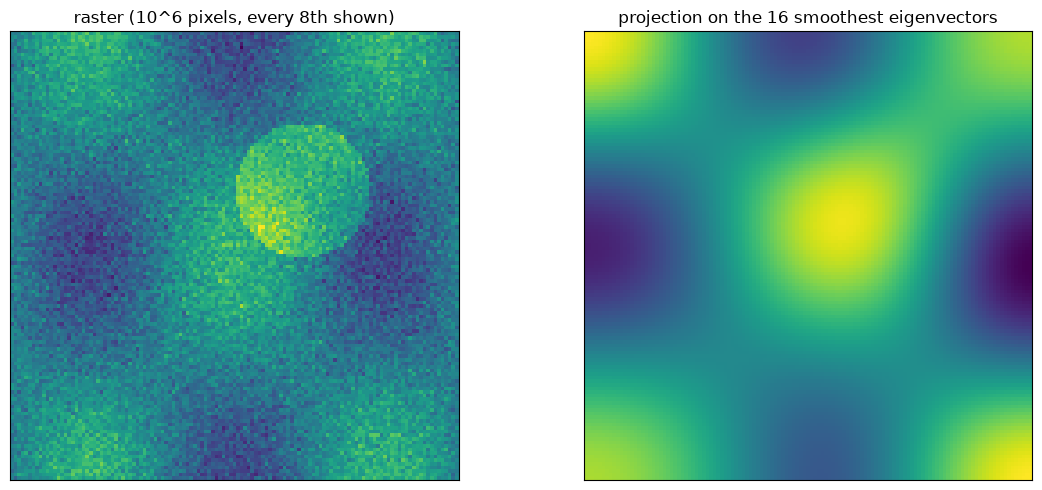

In [8]:
f = einx.id("h w -> (h w)", raster)
coef = einx.dot("n m, n -> m", U, f)
low_pass = einx.id("(h w) -> h w", U @ coef, h=n_side)

energy_raw = float(grid.dirichlet_energy(f))
energy_smooth = float(grid.dirichlet_energy(einx.id("h w -> (h w)", low_pass)))
print(
    f"Dirichlet energy: raster {energy_raw:.3e}, 16-mode projection {energy_smooth:.3e}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raster[::8, ::8], cmap="viridis")
axes[0].set_title("raster (10^6 pixels, every 8th shown)")
axes[1].imshow(low_pass[::8, ::8], cmap="viridis")
axes[1].set_title("projection on the 16 smoothest eigenvectors")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Graph Matérn priors on a k-NN graph

On scattered points there is no lattice, but a k-NN graph gives a geometry that follows the data: distances are measured *along the graph*. The graph Matérn kernel of Borovitskiy et al. (2021) is a spectral function of the Laplacian $L = U \Lambda U^\top$,

$$K = U\, \Phi(\Lambda)\, U^\top, \qquad \Phi(\lambda) \propto \left(\frac{2\nu}{\ell^2} + \lambda\right)^{-\nu},$$

scaled so that the average marginal variance $\mathrm{tr}(K) / N$ is 1. It is the covariance of the graph SPDE $(\kappa^2 + L)^{\nu/2} f = \mathcal W$ with $\kappa^2 = 2\nu/\ell^2$: $\nu$ sets smoothness and $\ell$ (in graph hops) sets the correlation range. A sample is $f = U \Phi(\Lambda)^{1/2} z$ with $z \sim \mathcal N(0, I)$.

The points below fill a horseshoe. Two points on either side of the gap are close in the plane but far apart along the graph.

In [9]:
rng = np.random.default_rng(0)
n_pts = 1500
theta = rng.uniform(0.15 * np.pi, 1.85 * np.pi, n_pts)
radius = np.sqrt(rng.uniform(0.5**2, 1.0**2, n_pts))
pts = jnp.asarray(np.column_stack([radius * np.cos(theta), radius * np.sin(theta)]))

knn = kl.knn_graph(pts, 8, ensure_connected=True)
print(
    f"k-NN graph: {knn.n_nodes} nodes, {knn.topology.n_edges} edges, "
    f"{kl.n_components_graph(knn)} connected component(s)"
)

lam_k, U_k = kl.laplacian_eigpairs(knn, n_pts, normalization="symmetric")
print(f"all {n_pts} eigenpairs (dense); smallest: {np.round(np.asarray(lam_k[:4]), 5)}")

k-NN graph: 1500 nodes, 6978 edges, 1 connected component(s)


all 1500 eigenpairs (dense); smallest: [-0.       0.00021  0.00082  0.00191]


`matern_graph_kernel` returns the dense $N \times N$ kernel. The same kernel comes from the eigenpairs and `graph_matern_spectrum`, which is also the route to large graphs: there one keeps only the smallest eigenpairs (a truncated, rank-$M$ prior).

In [10]:
K = kl.matern_graph_kernel(knn, nu=1.5, lengthscale=5.0)
phi = graph_matern_spectrum(lam_k, nu=1.5, lengthscale=5.0, n_nodes=n_pts)
K_spec = einx.dot("n m, p m -> n p", einx.multiply("n m, m -> n m", U_k, phi), U_k)
print(f"average marginal variance tr(K)/N = {float(jnp.trace(K)) / n_pts:.4f}")
print(f"max |K - U Phi U^T| = {float(jnp.max(jnp.abs(K - K_spec))):.1e}")
for M in (50, 200):  # a truncated prior keeps the M smallest eigenpairs
    print(
        f"variance kept by the {M} smallest eigenpairs: "
        f"{float(phi[:M].sum() / phi.sum()):.3f}"
    )

average marginal variance tr(K)/N = 1.0000
max |K - U Phi U^T| = 6.0e-15


variance kept by the 50 smallest eigenpairs: 0.335
variance kept by the 200 smallest eigenpairs: 0.616


The two kernels agree to rounding error. For this rough $\nu = 1.5$ prior a truncation needs many modes: the 50 smallest of the 1500 eigenpairs carry about a third of the prior variance and the 200 smallest about 62%.

Prior samples for three smoothness values and two lengthscales, all from the same white noise $z$:

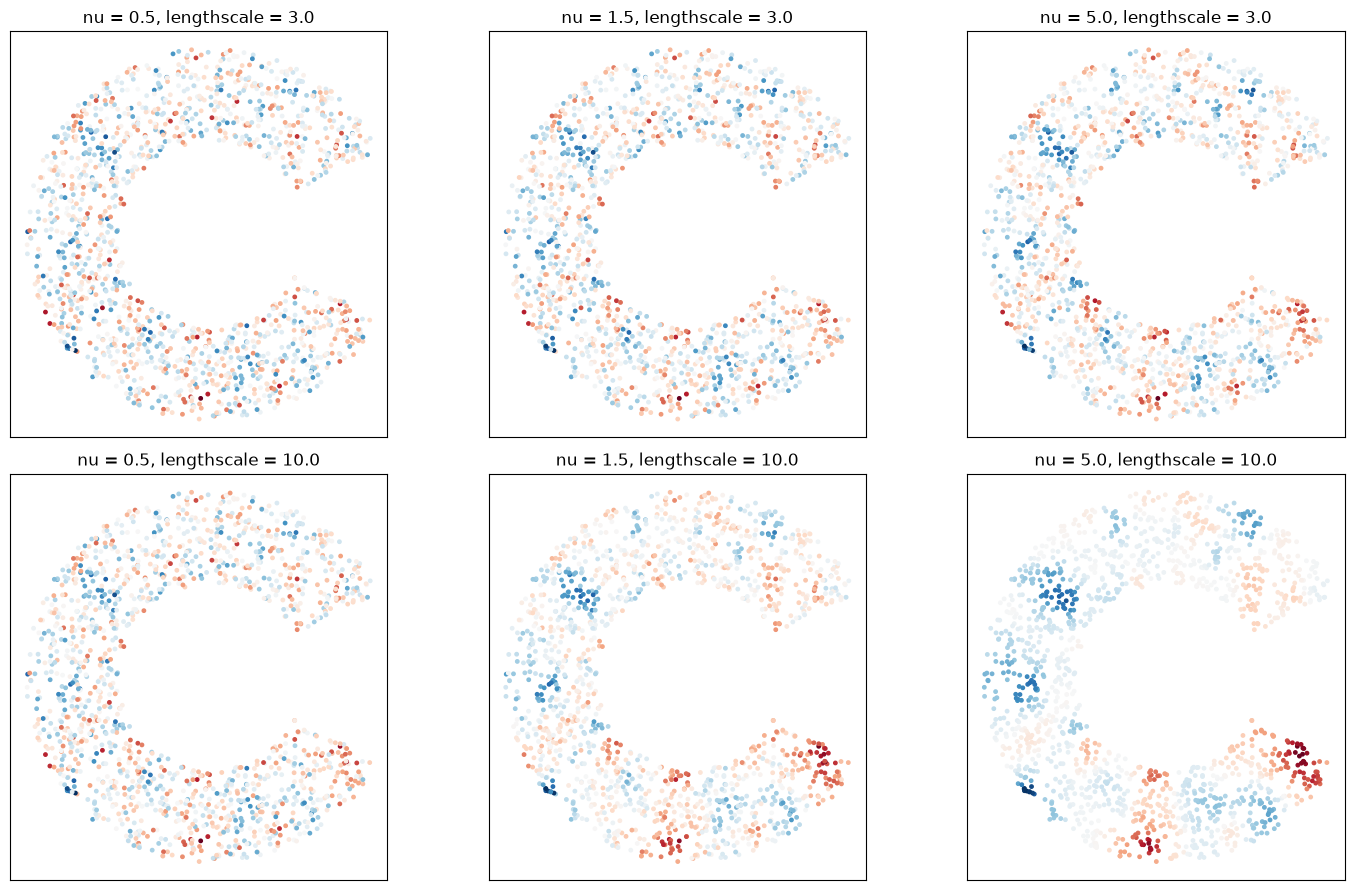

In [11]:
z = jax.random.normal(jax.random.key(0), (n_pts,))
nus = (0.5, 1.5, 5.0)
lengthscales = (3.0, 10.0)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, ell in enumerate(lengthscales):
    for col, nu in enumerate(nus):
        phi = graph_matern_spectrum(lam_k, nu=nu, lengthscale=ell, n_nodes=n_pts)
        sample = U_k @ (jnp.sqrt(phi) * z)
        ax = axes[row, col]
        ax.scatter(pts[:, 0], pts[:, 1], c=sample, s=6, cmap="RdBu_r")
        ax.set_title(f"nu = {nu}, lengthscale = {ell}")
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()

With $\nu = 1.5$ and $\nu = 5$, a longer lengthscale gives larger features and a larger $\nu$ gives smoother ones. With $\nu = 0.5$ the samples stay rough at both lengthscales: the spectrum decays so slowly that the high-frequency modes dominate.

The correlation with one node x, at the tip of the lower arm next to the gap, shows the graph geometry. It spreads along the lower arm and never reaches the tip of the upper arm, which is just as close in the plane:

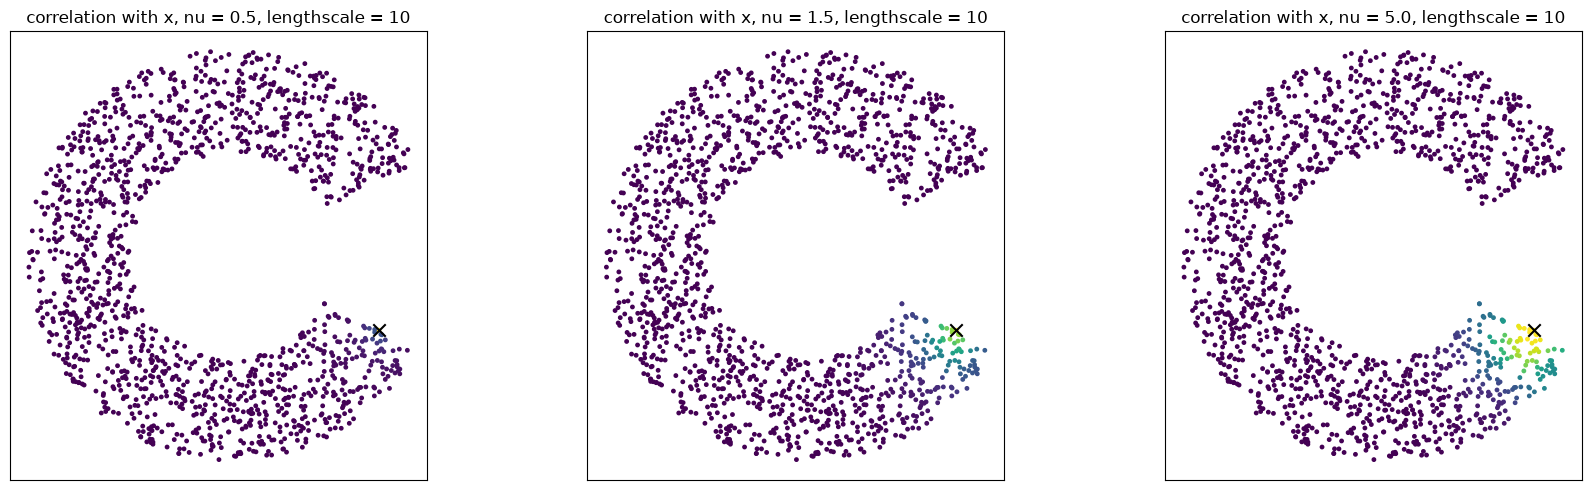

In [12]:
anchor = int(jnp.argmin(jnp.abs(pts[:, 0] - 0.75) + jnp.abs(pts[:, 1] - 0.0)))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nu in zip(axes, nus, strict=True):
    phi = graph_matern_spectrum(lam_k, nu=nu, lengthscale=10.0, n_nodes=n_pts)
    weighted = einx.multiply("n m, m -> n m", U_k, phi)
    cov = weighted @ U_k[anchor]
    var = einx.sum("n m -> n", weighted * U_k)
    corr = cov / jnp.sqrt(var * cov[anchor])
    ax.scatter(pts[:, 0], pts[:, 1], c=corr, s=6, cmap="viridis", vmin=0, vmax=1)
    ax.scatter(pts[anchor, 0], pts[anchor, 1], c="k", marker="x", s=80)
    ax.set_title(f"correlation with x, nu = {nu}, lengthscale = 10")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 3. Proximity graphs and ICAR priors on irregular sites

For points in two or three dimensions there are graphs with no $k$ to tune. The Delaunay triangulation contains a nested family,

$$\mathrm{EMST} \subseteq \mathrm{RNG} \subseteq \mathrm{GG} \subseteq \mathrm{DT},$$

the relative neighbourhood graph (no point closer to both ends), the Gabriel graph (no point inside the circle on the edge as diameter) and the Delaunay graph. All contain the Euclidean minimum spanning tree, so all are connected, with $O(N)$ edges. A k-NN graph with small $k$, by contrast, can fall apart into components when sites cluster.

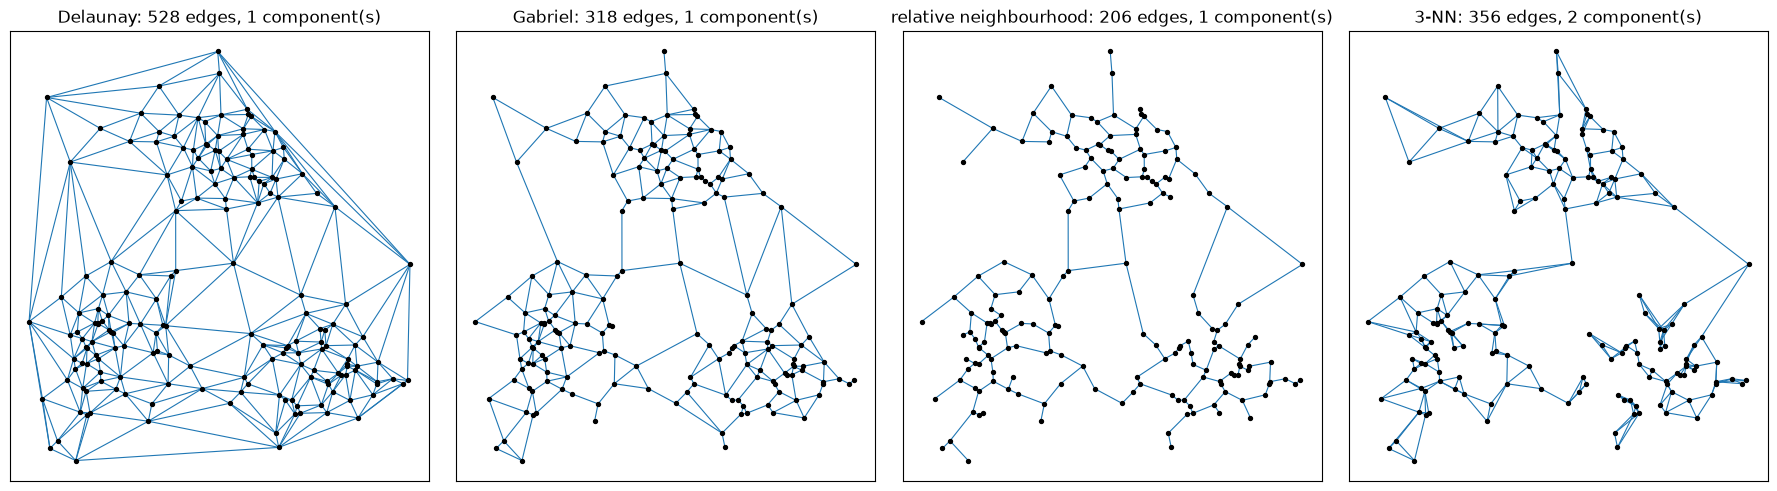

In [13]:
rng = np.random.default_rng(3)
centres = np.array([[0.2, 0.3], [0.75, 0.25], [0.5, 0.8]])
cluster_id = rng.integers(0, 3, 150)
sites = centres[cluster_id] + 0.09 * rng.normal(size=(150, 2))
sites = jnp.asarray(np.vstack([sites, rng.uniform(size=(30, 2))]))

graphs = {
    "Delaunay": kl.delaunay_graph(sites, weighting="connectivity"),
    "Gabriel": kl.gabriel_graph(sites, weighting="connectivity"),
    "relative neighbourhood": kl.relative_neighborhood_graph(
        sites, weighting="connectivity"
    ),
    "3-NN": kl.knn_graph(sites, 3, weighting="connectivity"),
}


def draw_edges(ax, graph, points, **kw):
    s, r = graph.topology.senders, graph.topology.receivers
    p = np.asarray(points)
    segments = einx.id("e c, e c -> e (1 + 1) c", p[s], p[r])
    ax.add_collection(LineCollection(segments, **kw))


fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
for ax, (name, graph) in zip(axes, graphs.items(), strict=True):
    draw_edges(ax, graph, sites, colors="C0", linewidths=0.8)
    ax.scatter(sites[:, 0], sites[:, 1], s=8, c="k", zorder=3)
    n_comp = kl.n_components_graph(graph)
    ax.set_title(f"{name}: {graph.topology.n_edges} edges, {n_comp} component(s)")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

The **intrinsic CAR (ICAR, Besag)** prior on a graph has precision $\tau R$ with structure matrix $R = L$, the unnormalised Laplacian: $p(x) \propto \exp(-\tfrac\tau2 \sum_{i \sim j} (x_i - x_j)^2)$. $R$ is singular, with one null direction per connected component (the component's indicator), so the prior is proper only on the subspace orthogonal to `graph_null_space(graph)`: one sum-to-zero constraint per component. `structure_matrix(graph, scaled=True)` applies the BYM2 scaling (Riebler et al., 2016): $R^\ast = sR$ with $s$ chosen so that the geometric mean of the constrained marginal variances is 1, so that $\tau$ means the same on every graph.

In [14]:
gabriel = graphs["Gabriel"]
R = kl.structure_matrix(gabriel, scaled=True)
null = kl.graph_null_space(gabriel)
print(f"structure matrix: {type(R).__name__}, null space {null.shape}")

R_dense = R.as_matrix()
eigval, eigvec = jnp.linalg.eigh(R_dense)
keep = eigval > 1e-6 * eigval[-1]
basis = eigvec[:, keep]
cov = einx.dot(
    "n m, p m -> n p", einx.divide("n m, m -> n m", basis, eigval[keep]), basis
)
geo_mean = float(jnp.exp(jnp.mean(jnp.log(jnp.diag(cov)))))
print(
    f"zero eigenvalues: {int((~keep).sum())}; "
    f"geometric-mean marginal variance: {geo_mean:.4f}"
)

structure matrix: SparseOperator, null space (180, 1)


zero eigenvalues: 1; geometric-mean marginal variance: 1.0000


A k-NN graph with small $k$ shows the per-component constraints: each component gets its own column in the null space, and its own scaling.

In [15]:
knn3 = graphs["3-NN"]
null3 = kl.graph_null_space(knn3)
sizes = einx.sum("n c -> c", null3 > 0)
print(f"3-NN graph: null space {null3.shape}, component sizes {np.asarray(sizes)}")

3-NN graph: null space (180, 2), component sizes [172   8]


A constrained ICAR sample is $x = V_+ \Lambda_+^{-1/2} z$ over the non-null eigenpairs of $R^\ast$: it sums to zero, and neighbouring sites take similar values.

|null^T x| = 1.1e-13


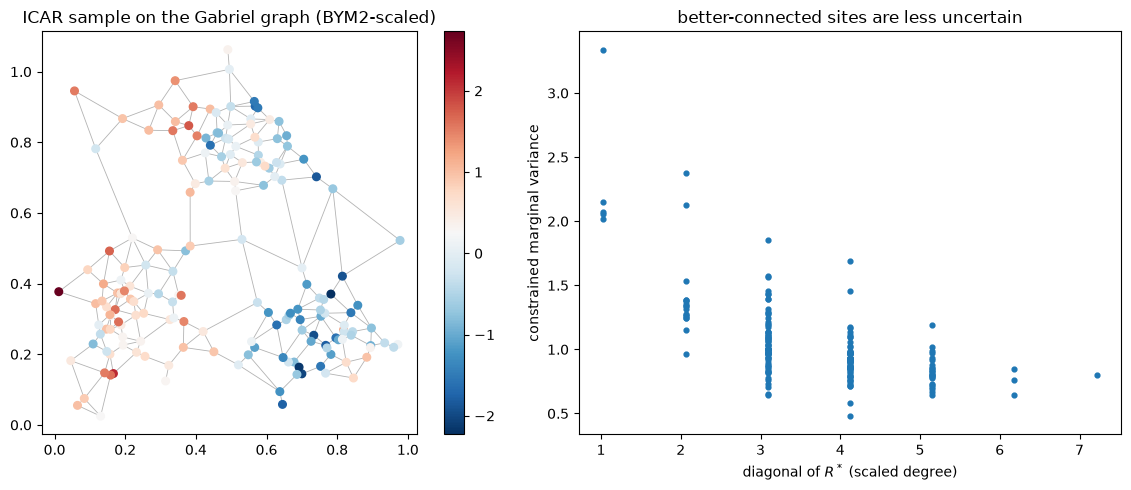

In [16]:
z_sites = jax.random.normal(jax.random.key(1), (int(keep.sum()),))
x_icar = eigvec[:, keep] @ (z_sites / jnp.sqrt(eigval[keep]))
print(f"|null^T x| = {float(jnp.abs(einx.dot('n c, n -> c', null, x_icar))[0]):.1e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_edges(axes[0], gabriel, sites, colors="0.7", linewidths=0.6)
sc = axes[0].scatter(sites[:, 0], sites[:, 1], c=x_icar, s=30, cmap="RdBu_r", zorder=3)
plt.colorbar(sc, ax=axes[0])
axes[0].set_title("ICAR sample on the Gabriel graph (BYM2-scaled)")
axes[0].set_aspect("equal")
axes[1].scatter(jnp.diag(R_dense), jnp.diag(cov), s=12)
axes[1].set_xlabel("diagonal of $R^*$ (scaled degree)")
axes[1].set_ylabel("constrained marginal variance")
axes[1].set_title("better-connected sites are less uncertain")
plt.tight_layout()
plt.show()

A triangulation is also a finite-element mesh. `mesh_graph(vertices, triangles, weighting="cotangent")` weights each edge by $\tfrac12(\cot\alpha_{ij} + \cot\beta_{ij})$, the angles opposite it, so its Laplacian is the P1 stiffness matrix: the discretisation that SPDE (Matérn-field) priors on irregular meshes are built on. The weights must be non-negative for a graph, and `mesh_graph` raises rather than clamp a negative one. On the Delaunay triangulation of the scattered sites above it raises, because some triangles on the convex hull have an obtuse angle facing a boundary edge, which has no second triangle to compensate. The mesh below is a jittered triangular lattice instead: its triangles are close to equilateral, no angle reaches 90°, and every weight is positive.

mesh: 144 vertices, 242 triangles, 385 edges
max |stiffness @ 1| = 4.4e-16
cotangent weights: min 0.143, median 0.567, max 0.933


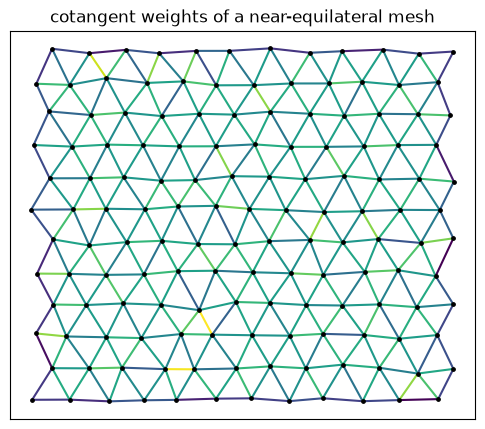

In [17]:
n_mesh = 12
row, col = np.mgrid[0:n_mesh, 0:n_mesh].astype(float)
lattice_xy = np.stack([col + 0.5 * (row % 2), row * np.sqrt(3) / 2]) / (n_mesh - 1)
jitter = 0.05 / (n_mesh - 1) * np.random.default_rng(4).normal(size=lattice_xy.shape)
vertices = jnp.asarray(einx.id("c h w -> (h w) c", lattice_xy + jitter))
node = einx.id("(h w) -> h w", np.arange(n_mesh * n_mesh), h=n_mesh)
triangles = []
for j in range(n_mesh - 1):
    for i in range(n_mesh - 1):
        p, q = node[j, i], node[j, i + 1]  # this row
        r, t = node[j + 1, i], node[j + 1, i + 1]  # the row above
        triangles += [(p, q, r), (q, t, r)] if j % 2 == 0 else [(p, t, r), (p, q, t)]
triangles = np.array(triangles)

mesh = kl.mesh_graph(vertices, triangles, weighting="cotangent")
stiffness = mesh.laplacian_operator()
row_sums = stiffness.mv(jnp.ones(mesh.n_nodes))
w = np.asarray(mesh.weights)
print(
    f"mesh: {mesh.n_nodes} vertices, {len(triangles)} triangles, "
    f"{mesh.topology.n_edges} edges"
)
print(f"max |stiffness @ 1| = {float(jnp.max(jnp.abs(row_sums))):.1e}")
print(
    f"cotangent weights: min {w.min():.3f}, median {np.median(w):.3f}, "
    f"max {w.max():.3f}"
)

fig, ax = plt.subplots(figsize=(6, 6))
draw_edges(ax, mesh, vertices, array=w, cmap="viridis", linewidths=1.5)
ax.scatter(vertices[:, 0], vertices[:, 1], s=6, c="k", zorder=3)
ax.set_title("cotangent weights of a near-equilateral mesh")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## 4. Spatial-spectral embeddings of images

Lattices and spectral data meet in hyperspectral images. Weighting the pixel lattice by spectral similarity gives the spatial-spectral graph of Cahill, Czaja & Messinger (2014), whose Laplacian is a Schrödinger potential that pulls together pixels that are adjacent *and* alike:

```python
X = einx.id("h w b -> (h w) b", cube)
spectral = kl.knn_graph(X, 10)                                # spectra only
V = kl.spatial_spectral_graph(X, kl.grid_graph(cube.shape[:2])).laplacian_operator()
se = kl.SchrodingerEigenmaps(n_components=4, alpha=10.0, eigen_solver="arpack")
Y = se.fit(X, V, graph=spectral).embedding                    # sparse throughout
```

The [spatial-spectral Schrödinger eigenmaps](spatial_spectral_eigenmaps.ipynb) notebook runs this on a synthetic hyperspectral cube with two spectrally near-identical regions, compares it with Laplacian eigenmaps by k-means ARI, sweeps $\alpha$ with and without the trace normalisation, and scales it up with approximate neighbours.

## Summary

- A face-connected `GridGraph` has Kronecker-structured Laplacian eigenpairs: `laplacian_eigpairs` returns the smallest ones of a $10^6$-pixel raster at the cost of two 1-D eigendecompositions, with no $N \times N$ matrix.
- The graph Matérn kernel is a spectral function of the Laplacian. `matern_graph_kernel` gives the dense kernel; `laplacian_eigpairs` plus `graph_matern_spectrum` gives the same prior, and its truncation for large graphs.
- Delaunay, Gabriel and relative neighbourhood graphs are connected and parameter-free; `structure_matrix` turns any graph into a (BYM2-scaled) ICAR structure, with `graph_null_space` supplying one sum-to-zero constraint per component, and `mesh_graph` gives the FEM stiffness matrix of a triangle mesh whose cotangent weights are non-negative.